# Simulation of Relaxation Dynamics and Time-Resolved Spectra for a Coupled Doublet–Triplet System


This notebook demonstrates the construction of a relaxation model for a spin system consisting of a doublet (S=½) and a triplet (S=1) with exchange coupling.  
We will:

1. Build the spin samples (doublet, triplet, and their coupled complex).
2. Define relaxation pathways (population decay, Zeeman thermalization, dephasing).
3. Compute stationary (CW) spectra.
4. Simulate time‑resolved spectra for different exchange coupling strengths.
5. Visualize and compare the results for different computation methods

We strongly recommend that you first review Example 1, then Example 5, and then begin working with this notebook.


\
\
\
\
\
\
For any questions, please contact Arkady Samsonenko via: \
Telegram: @Arkady_Samsonenko \
Email: a.samsonenko.tomo.nsc.ru\
\
\
The last notebook update: 2026.08.01

In [1]:
# Import necessary libraries
%load_ext autoreload
%autoreload 2

import sys
import os
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', "..")))

# Import Mars library components
import mars
from mars import spin_model, spectra_manager, mesher, constants
from mars import utils
from mars import population

# # Let's import some useful functions for plotting simulation results over time.
from mars import visualization

In [2]:
dtype = torch.float64
device = torch.device("cpu")

# Experimental parameters
freq_res = 9.8 * 1e9          # 9.8 GHz microwave frequency
temperature = torch.tensor(100.0, dtype=dtype, device=device)   # Temperature in Kelvin

# 1. Sample Construction


We define a function get_samples that creates three MultiOrientedSample objects:

1) Doublet (S=1/2) – has an anisotropic g‑tensor.

2) Triplet (S=1) – has a zero‑field splitting (ZFS) interaction.

3) Complex – a coupled system of doublet and triplet with an isotropic exchange interaction.



> Note: In this notebook, the term *exchange interaction* refers to the Hamiltonian term
>
  $$
  \mathcal{H}_{\mathrm{ex}} = J\,S_1 S_2.
  $$
>
> In the original manuscript, the corresponding term is written as
>
  $$
  \mathcal{H}_{\mathrm{ex}} = -2J\,S_1 S_2.
  $$
>
> Thus, the notebook convention differs from the manuscript convention by a factor of $-2$.

In [3]:
# Let's start from the sample creation
def get_samples(exchange_value: float):
    """
    Create the doublet, triplet, and coupled complex samples.

    :param exchange_value: Exchange coupling constant (in Hz) between doublet and triplet.
    :return: Doublet (S=1/2) sample with anisotropic g-tensor, Triplet (S=1) sample with ZFS (D=500 MHz, E=100 MHz), Coupled doublet–triplet system with the given exchange interaction.
    """
    g_tensor_triplet = spin_model.Interaction([2.000, 2.002, 2.004], dtype=dtype, device=device)
    zfs_interaction = spin_model.DEInteraction([500e6, 100e6], dtype=dtype, device=device)  # 500 and 100 MHz

    base_spin_system = spin_model.SpinSystem(
        electrons=[1.0],  # S=1 triplet
        g_tensors=[g_tensor_triplet],
        electron_electron=[(0, 0, zfs_interaction)]
    )

    triplet = spin_model.MultiOrientedSample(
        base_spin_system=base_spin_system,
        ham_strain=0.0,
        gauss=0.002,
        lorentz=0.0015,
        device=device,
        dtype=dtype
    )
    
    # Doublet (S=1/2) – anisotropic g
    g_tensor_doublet = spin_model.Interaction([2.02, 2.04, 2.25], dtype=dtype, device=device)
    base_spin_system = spin_model.SpinSystem(
        electrons=[0.5],  # S=0.5
        g_tensors=[g_tensor_doublet],
    )
    doublet = spin_model.MultiOrientedSample(
        base_spin_system=base_spin_system,
        ham_strain=0.0,
        gauss=0.002,
        lorentz=0.002,
        device=device,
        dtype=dtype
    )
    
    # Complex coupled system: doublet + triplet with exchange
    exchange_interaction = spin_model.Interaction(exchange_value, dtype=dtype, device=device)   # Here we define exchange interaction as JS1S2. In the article this is -2JS1S2
    base_spin_system = spin_model.SpinSystem(
        electrons=[0.5, 1.0],  # S=0.5 triplet
        g_tensors=[g_tensor_doublet, g_tensor_triplet],
        electron_electron=[(1, 1, zfs_interaction), (0, 1, exchange_interaction)],
    )

    sample_complex = spin_model.MultiOrientedSample(
        base_spin_system=base_spin_system,
        ham_strain=0.0,
        gauss=0.002,
        lorentz=0.002,
        device=device,
        dtype=dtype
    )
    return doublet, triplet, sample_complex

# 2.Relaxation Contexts

We define a function get_contexts that builds the population.Context objects for each subsystem and for the coupled system.
The contexts describe:

1) Doublet: initial populations (Boltzmann) and a rate for spin‑lattice relaxation (thermal rates between its two Zeeman levels).

2) Triplet: initial population in one sublevel (in the xyz basis), rate among triplet sublevels

3) Complex: combines the triplet and doublet contexts using mars.multiply (tensor product of the two density matrices) and adds a dephasing term.

In [4]:
def get_contexts(temperature, doublet, triplet, sample_complex):
    """
    Build relaxation contexts for the doublet, triplet, and coupled system.

    :param temperature: Temperature used for Boltzmann populations.
    :param doublet: Doublet sample.
    :param triplet: Triplet sample.
    :param sample_complex: Coupled sample.
    :return: Doublet context with thermal rates,
    Triplet context with initial population and thermal rates,
    Coupled context (product of triplet and doublet) with dephasing.
    """
    
    # Compute Boltzmann populations for doublet
    fields = torch.tensor([0.34], dtype=dtype)
    F, _, _, Gz = doublet.get_hamiltonian_terms()
    H = F + Gz * fields
    H  = H.unsqueeze(-3)
    energies, full_system_vectors = torch.linalg.eigh(H)

    populations_doublet = torch.softmax(
        constants.unit_converter(-energies, "Hz_to_K") / temperature, dim=-1
                                )[0, 0]
    
    # Triplet context in xyz basis with initial population in the third sublevel
    context_triplet_xyz = population.Context(
        basis="xyz",
        sample=triplet,
        init_populations=[0.0, 0.0, 1.0],
        decay_rates=[0.0, 0.0, 0.0],
        dtype=dtype,
    )

    # Triplet thermalisation among Zeeman sublevels
    context_triplet_zeeman = population.Context(
        basis="zeeman",
        sample=triplet,
        thermal_rates=torch.tensor([[-0.0, 1e3, 0.0],
                                     [1e3, -0.0, 1e3],
                                     [0.0, 1e3, -0.0]], dtype=dtype),
        dtype=dtype,
    )

    # Doublet context with initial thermal populations and thermal rates
    context_doublet_free = population.Context(
        basis="zeeman",
        sample=doublet,
        init_populations=populations_doublet,
        thermal_rates=torch.tensor([[-0.0, 1e4],
                                     [1e4, -0.0]], dtype=dtype),
        dtype=dtype
    )

    # Doublet context (for stationary spectra) – we use the same as free
    context_doublet = context_doublet_free

    # Dephasing for the coupled system
    context_dephasing = population.Context(
        basis="eigen",
        sample=sample_complex,
        dephasing=[1e6 for _ in range(6)],
        dtype=dtype
    )

    # Coupled context: tensor product of triplet (xyz + zeeman) and doublet contexts
    context_triplet_total = context_triplet_xyz + context_triplet_zeeman
    context_complex = mars.multiply((context_triplet_total, context_doublet_free)) + context_dephasing

    return context_doublet, context_triplet_total, context_complex

In [5]:
doublet, triplet, sample_complex = get_samples(100e6)
context_doublet, context_triplet, context_complex = get_contexts(temperature, doublet, triplet, sample_complex)

# 3. Steady-State (CW) Spectra

We compute stationary absorption spectra for the doublet, triplet, and coupled system using both the direct Hamiltonian and the secular approximation.
This allows us to see the effect of the secular approximation on the stationary spectrum.

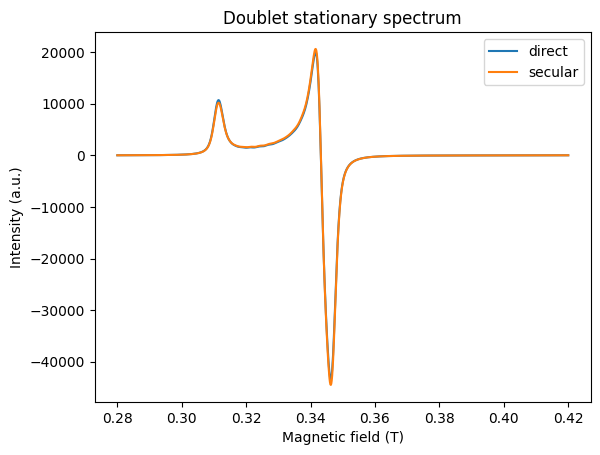

In [6]:
# Field sweep for stationary spectra
fields = torch.linspace(0.28, 0.42, 1000, dtype=dtype, device=device)

# Doublet
stationary = spectra_manager.StationarySpectra(
    freq=freq_res,
    sample=doublet,
    harmonic=1.0,
    context=context_doublet,
    temperature=temperature,
    device=device,
    dtype=dtype
)
out = stationary(doublet, fields)

stationary_sec = spectra_manager.StationarySpectra(
    freq=freq_res,
    sample=doublet,
    harmonic=1.0,
    context=context_doublet,
    temperature=temperature,
    hamiltonian_mode="secular",
    device=device,
    dtype=dtype
)
out_sec = stationary_sec(doublet, fields)

plt.figure()
plt.plot(fields.cpu().numpy(), out.cpu().numpy(), label="direct")
plt.plot(fields.cpu().numpy(), out_sec.cpu().numpy(), label="secular")
plt.legend()
plt.title("Doublet stationary spectrum")
plt.xlabel("Magnetic field (T)")
plt.ylabel("Intensity (a.u.)")
plt.show()

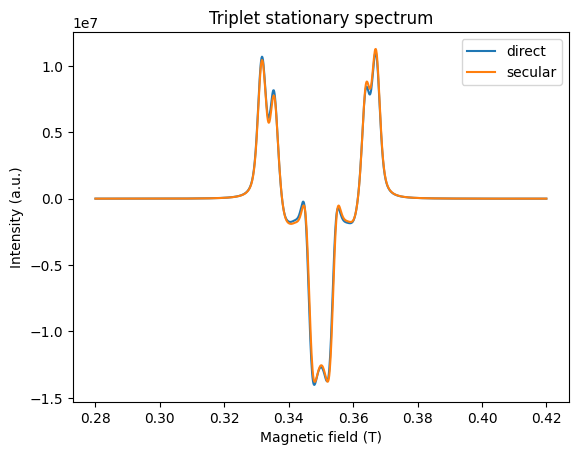

In [7]:
# Triplet
stationary = spectra_manager.StationarySpectra(
    freq=freq_res,
    sample=triplet,
    harmonic=1.0,
    context=context_triplet,
    temperature=temperature,
    device=device,
    dtype=dtype
)
out = stationary(triplet, fields)

stationary_sec = spectra_manager.StationarySpectra(
    freq=freq_res,
    sample=triplet,
    harmonic=1.0,
    context=context_triplet,
    temperature=temperature,
    hamiltonian_mode="secular",
    device=device,
    dtype=dtype
)
out_sec = stationary_sec(triplet, fields)

plt.figure()
plt.plot(fields.cpu().numpy(), out.cpu().numpy(), label="direct")
plt.plot(fields.cpu().numpy(), out_sec.cpu().numpy(), label="secular")
plt.legend()
plt.title("Triplet stationary spectrum")
plt.xlabel("Magnetic field (T)")
plt.ylabel("Intensity (a.u.)")
plt.show()

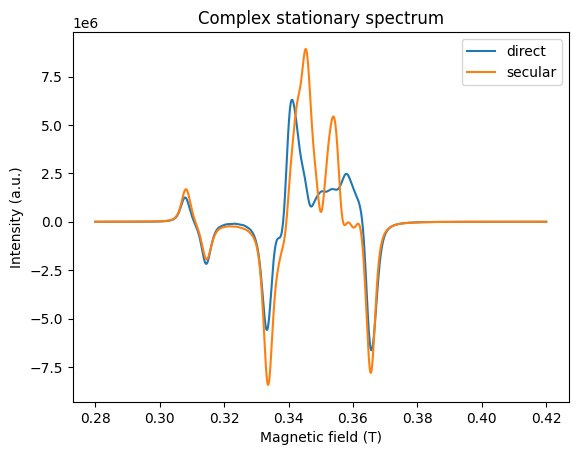

In [8]:
# Complex
stationary = spectra_manager.StationarySpectra(
    freq=freq_res,
    sample=sample_complex,
    harmonic=1.0,
    context=context_complex,
    temperature=temperature,
    device=device,
    dtype=dtype
)
out = stationary(sample_complex, fields)

stationary_sec = spectra_manager.StationarySpectra(
    freq=freq_res,
    sample=sample_complex,
    harmonic=1.0,
    context=context_complex,
    temperature=temperature,
    hamiltonian_mode="secular",
    device=device,
    dtype=dtype
)
out_sec = stationary_sec(sample_complex, fields)

plt.figure()
plt.plot(fields.cpu().numpy(), out.cpu().numpy(), label="direct")
plt.plot(fields.cpu().numpy(), out_sec.cpu().numpy(), label="secular")
plt.legend()
plt.title("Complex stationary spectrum")
plt.xlabel("Magnetic field (T)")
plt.ylabel("Intensity (a.u.)")
plt.show()

It is noticed, that for the high exchange constant the secular approximation fails to reproduce the correct CW spectrum

# 4. Time‑Resolved Spectra Simulation

We now set up functions to create time‑resolved spectrum calculators and to run simulations.

In [9]:
def get_creators(doublet, triplet, sample_complex):
    """
    Create time‑resolved spectrum calculators for different methods.

    :param doublet: The spin samples.
    :param triplet: The spin samples.
    :param sample_complex: The spin samples.
    :return: List of dict, each containing 'name' (str) and 'instance' (a spectrum manager object).
    """
    harmonic = 0
    fields = torch.linspace(0.28, 0.42, 1000, dtype=dtype, device=device)
    context_doublet, context_triplet, context_complex  = get_contexts(temperature, doublet, triplet, sample_complex)
    creators = [
        {
            "name": "Coupled",
            "instance": spectra_manager.CoupledTimeSpectra(
                freq=freq_res,
                sample=sample_complex,
                harmonic=harmonic,
                context=context_complex,
                temperature=temperature,
                hamiltonian_mode="direct",
                device=device,
                dtype=dtype
            )
        },
        {
            "name": "Density (RWA)",
            "instance": spectra_manager.DensityTimeSpectra(
                freq=freq_res,
                populator="rwa",
                sample=sample_complex,
                harmonic=harmonic,
                context=context_complex,
                temperature=temperature,
                device=device,
                dtype=dtype
            )
        },
        {
            "name": "Density (Propagator)",
            "instance": spectra_manager.DensityTimeSpectra(
                freq=freq_res,
                populator="propagator",
                sample=sample_complex,
                harmonic=harmonic,
                context=context_complex,
                temperature=temperature,
                hamiltonian_mode="direct",
                device=device,
                dtype=dtype
            )
        }
    ]
    return creators

In [10]:
def run_simulation(creators, doublet, triplet, sample_complex, tot_points, limit):
    """
    Run time‑resolved simulations for all creators and normalise spectra.

    :param creators: List of creator dictionaries as returned by get_creators.
    :param doublet: Spin samples.
    :param triplet: Spin samples.
    :param sample_complex: Spin samples.
    :param tot_points: Number of time points.
    :param limit: Maximum time (seconds).
    :return: List of dict, each containing 'name' and a 'long' dict with 'time' and 'spectrum'.
    """
    fields = torch.linspace(0.28, 0.42, 1000, dtype=dtype, device=device)
    time_long = torch.linspace(0.0, limit, tot_points, dtype=dtype, device=device)
    results = []

    print("Running simulations...")
    for creator_data in creators:
        creator = creator_data["instance"]
        name = creator_data["name"]
        print(f"Simulating {name}...")
        spec_long = creator(sample_complex, fields, time_long)
        results.append({
            "name": name,
            "long": {"time": time_long, "spectrum": spec_long}
        })

    # Normalise to the intensity at t = 9 µs
    print("Normalizing spectra...")
    target_norm_time = 9e-6
    for res in results:
        t_long = res["long"]["time"]
        spec_long = res["long"]["spectrum"]
        idx_norm = torch.argmin(torch.abs(t_long - target_norm_time)).item()
        max_val = torch.max(torch.abs(spec_long[idx_norm, :]))
        if max_val < 1e-12:
            max_val = 1.0
        res["long"]["spectrum"] = spec_long / max_val
        print(f"{res['name']}: Normalized by factor {max_val:.4e} at t=9 us")

    return results

# 5. Exchange‑Coupling Dependence

We now sweep over three exchange coupling values and simulate the time‑resolved spectra for a longer time window (0‑100 µs).
This allows us to see how the the relaxation and spectra differ depending on the computation methon and the connection between spin centers

In [11]:
J_values = [1e6, 50e6, 300e6]
results = []
for J in J_values:
    doublet, triplet, sample_complex = get_samples(J)
    creators = get_creators(doublet, triplet, sample_complex)
    res = run_simulation(creators, doublet, triplet, sample_complex, 800, 100e-6)
    results.append(res)

Running simulations...
Simulating Coupled...
Simulating Density (RWA)...
Simulating Density (Propagator)...
Normalizing spectra...
Coupled: Normalized by factor 2.8711e+04 at t=9 us
Density (RWA): Normalized by factor 5.4680e+03 at t=9 us
Density (Propagator): Normalized by factor 2.2392e+05 at t=9 us
Running simulations...
Simulating Coupled...
Simulating Density (RWA)...
Simulating Density (Propagator)...
Normalizing spectra...
Coupled: Normalized by factor 2.8543e+04 at t=9 us
Density (RWA): Normalized by factor 6.6557e+03 at t=9 us
Density (Propagator): Normalized by factor 2.1653e+05 at t=9 us
Running simulations...
Simulating Coupled...
Simulating Density (RWA)...
Simulating Density (Propagator)...
Normalizing spectra...
Coupled: Normalized by factor 2.7064e+04 at t=9 us
Density (RWA): Normalized by factor 6.6879e+03 at t=9 us
Density (Propagator): Normalized by factor 2.0843e+05 at t=9 us


### 5.1 Visualisation of 2D spectra for different J

We can plot the 2D spectra for one of the methods (e.g., "Density (Propagator)") and for each J value.

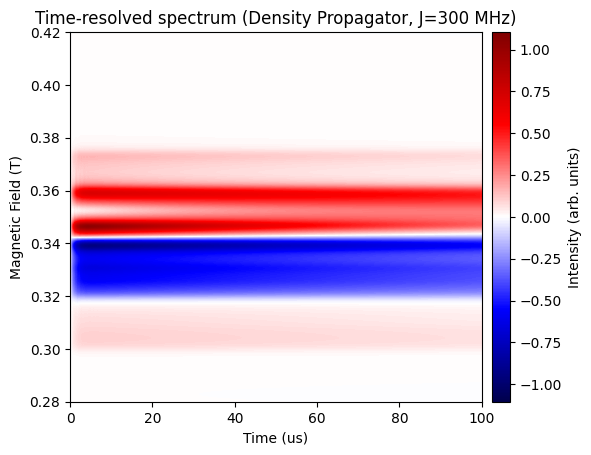

In [15]:
# Example: plot for the last J value (300 MHz) using the propagator method
spectrum = results[-1][2]["long"]["spectrum"]  # index 2 = Density (Propagator)

visualization.plot_2d_timeresolved(
    fields,
    results[-1][2]["long"]["time"],
    spectrum,
    time_unit="us"
)
plt.title("Time-resolved spectrum (Density Propagator, J=300 MHz)")
plt.show()

### 5.2 Field slices at different times

To compare the different methods and J values, we extract slices at two time points (0.5 µs - beggining and 100 µs - long relaxation) and plot the field dependence.

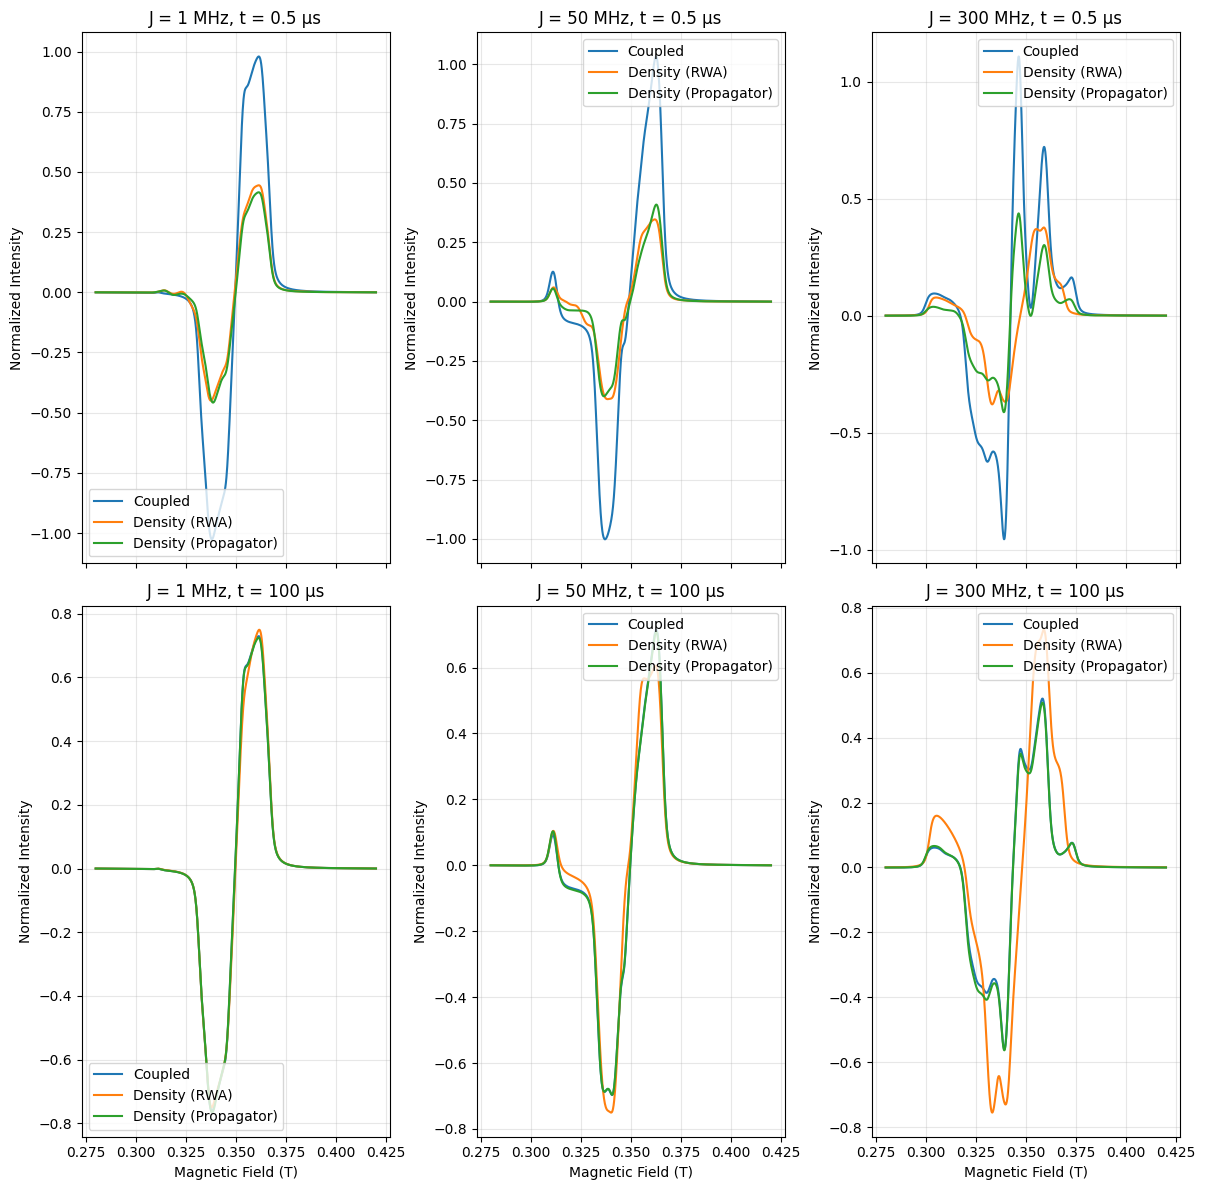

In [16]:
slice_times = [0.5e-6, 100e-6]
slice_labels = ["0.5 µs", "100 µs"]

fig2, axes = plt.subplots(2, 3, figsize=(12, 12), sharex=True)
fields_cpu = fields.cpu().numpy()

for i, result in enumerate(results):          # loop over J values
    for j, (t_target, t_label) in enumerate(zip(slice_times, slice_labels)):
        ax = axes[j][i]
        ax.set_title(f"J = {J_values[i]/1e6:.0f} MHz, t = {t_label}")
        ax.set_ylabel("Normalized Intensity")
        if j == 1:
            ax.set_xlabel("Magnetic Field (T)")

        # Plot all three methods
        for spec_num, res in enumerate(result):
            t_arr = res["long"]["time"]
            spec_arr = res["long"]["spectrum"]
            idx = torch.argmin(torch.abs(t_arr - t_target)).item()
            slice_data = spec_arr[idx, :].cpu().numpy()
            ax.plot(fields_cpu, slice_data, label=res["name"])

        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1) The coupled spectrum does not account for the T2 relaxation time required to establish the transverse magnetization.

2) In the long-relaxation regime, the coupled and propagator methods are in close agreement.

3) The RWA remains accurate even for J = 50 MHz.